### Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import torchaudio
from IPython.lib.display import Audio
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from src.config import CONFIG
from src.preprocessing import get_waveform_transformer, get_spectrogram_transformer
from src.utils import get_random_audio

warnings.filterwarnings("ignore", category=UserWarning)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
INPUT_DIR = Path('../../data/audioMNIST')

### Visualising audio data as Gammatone Spectrograms

STFT kernels created, time used = 0.0097 seconds
STFT filter created, time used = 0.0019 seconds
Gammatone filter created, time used = 0.0019 seconds


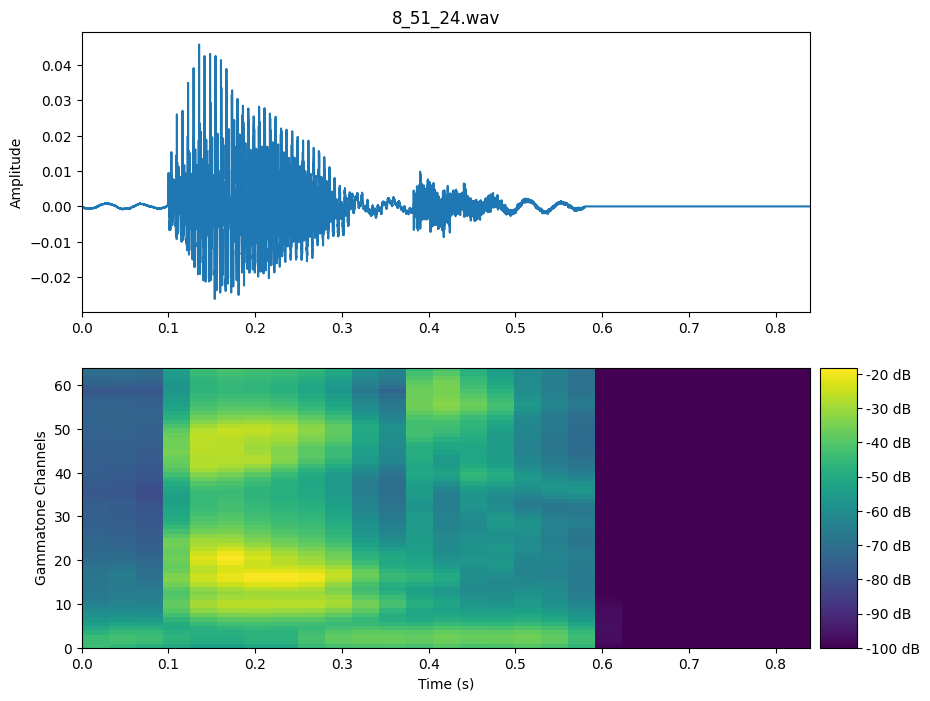

Original: 27837 samples (0.58s)
Preprocessed: 13440 samples (0.84s)


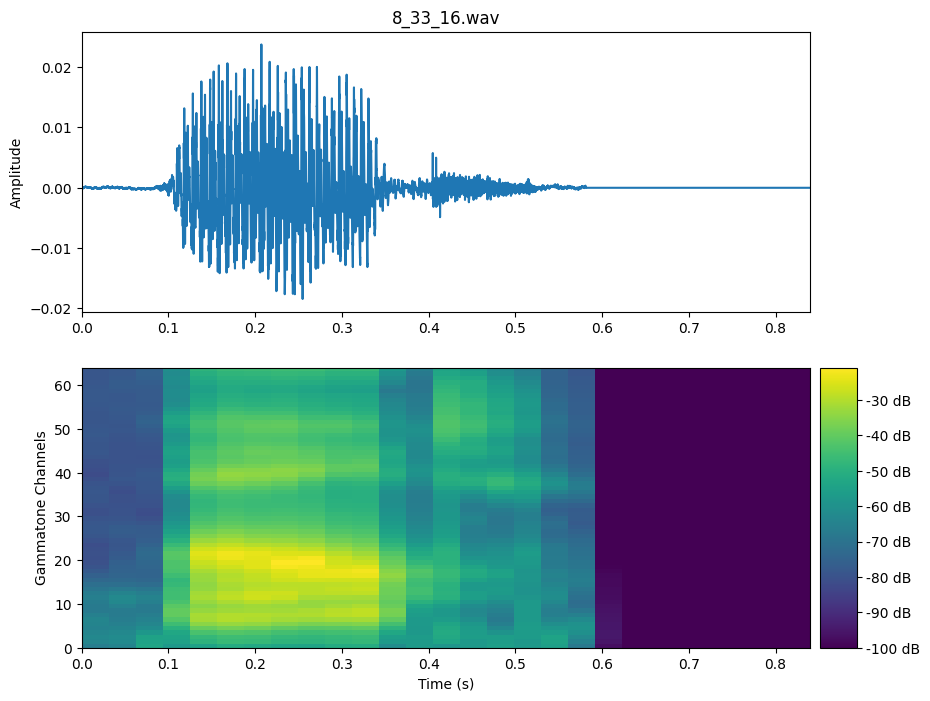

Original: 27930 samples (0.58s)
Preprocessed: 13440 samples (0.84s)


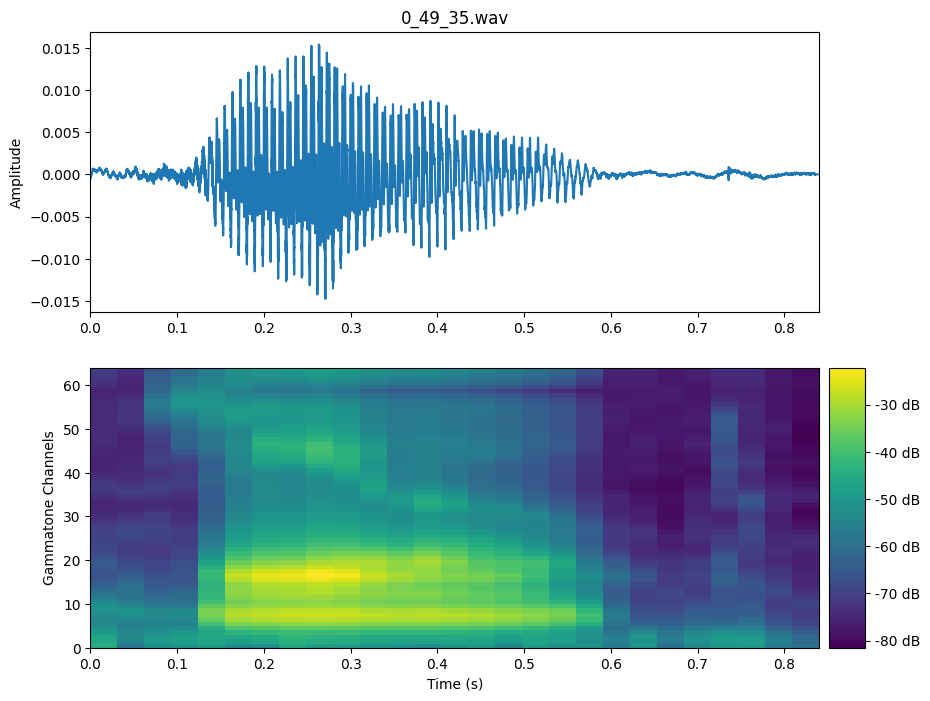

Original: 40116 samples (0.84s)
Preprocessed: 13440 samples (0.84s)


In [3]:
def visualise_audio_data() -> None:
    waveform_transformer = get_waveform_transformer()
    spectrogram_transformer = get_spectrogram_transformer(filterbank='gammatone')

    for i in range(3):
        file = get_random_audio(INPUT_DIR)

        raw_waveform, raw_sample_rate = torchaudio.load(file, normalize=True)
        new_waveform = waveform_transformer(raw_waveform)
        gammatone_spectrogram = spectrogram_transformer(new_waveform)

        new_samples = new_waveform.shape[1]
        new_duration = new_samples / CONFIG.audio.target_sample_rate

        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

        # Waveform
        ax1.plot(np.linspace(0, new_duration, new_samples), new_waveform.t().numpy())
        ax1.set_title(file.name)
        ax1.set_xlim(0, new_duration)
        ax1.set_ylabel('Amplitude')

        # Placeholder to allow the two graphs to align
        div1 = make_axes_locatable(ax1)
        cax1 = div1.append_axes("right", size="5%", pad=0.1)
        cax1.axis("off")

        # Gammatone Spectrogram
        img = ax2.imshow(
            gammatone_spectrogram[0].numpy(),
            origin='lower',
            aspect='auto',
            cmap='viridis',
            extent=[0, new_duration, 0, CONFIG.audio.n_mels],
        )
        ax2.set_ylabel('Gammatone Channels')
        ax2.set_xlabel('Time (s)')

        div2 = make_axes_locatable(ax2)
        cax2 = div2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(img, cax=cax2, format='%+2.0f dB')

        plt.show()

        display(Audio(data=new_waveform, rate=CONFIG.audio.target_sample_rate))
        print(f'Original: {raw_waveform.shape[1]} samples ({raw_waveform.shape[1]/raw_sample_rate:.2f}s)')
        print(f'Preprocessed: {new_samples} samples ({new_duration:.2f}s)')

visualise_audio_data()